# Singapore Job Market Analysis

Welcome! In the world of Data, the quality of your insights is directly tied to the quality of your data. This notebook guides you through a professional data cleaning workflow using a dataset of Singapore job postings.

### **Learning Objectives:**
1. **Analytical Framework:** Define problem statement and audit data availability before touching the code.
2. **Deduplication:** Distinguish between row-level duplicates and unique identifier overlaps.
3. **Missing Value Management:** Apply the "Integrity-First" approach to handle holes in data.
4. **Outlier Detection:** Use statistical methods to separate data entry errors from market diversity.
5. **Unpacking Data:** Extract data from JSON strings
6. **Data Visualisation and Key Insights:** Analysing the cleaned dataset and drawing key insights to answer problem statement

## 0. The Analytical Framework: Planning Your Approach

Before cleaning, we must ensure our efforts are aligned with the business objective. We will follow a three-step pre-cleaning audit.

### **Step A: Define the Problem Statement**
> "Identify current salary benchmarks for **Junior executive** vs. **Senior executive** roles in Singapore to help job seekers set realistic expectations."

### **Step B: Identify Key Question**

Next, we need to identify the key question(s). The Problem Statement is a broad objective focused on overall market transparency for job seekers, whereas the Key Question is a specific, measurable data point used to quantify the "experience premium" within a targeted industry. In this case, our key question is

1. What is the **median salary** for "Junior executive" vs. "Senior executive" roles in a particular sector?

### **Step C: Audit Metadata & Data Availability**

After identifying the key question, we need to understand what data is available. A data dictionary containing information on the available columns can be found in the link shared in class.

We then categorize our columns to see what is immediately usable, what needs work, and what is missing.

| Data Status | Definition | Examples in This Dataset | Implication |
| :--- | :--- | :--- | :--- |
| **Available** | Ready for immediate calculation. | `average_salary`, `positionLevels` | Use as-is, subject to data-cleaning checks. |
| **Available but Hidden** | Requires transformation (e.g., JSON parsing). | `categories` (stored as JSON strings), `salary_minimum`, `salary_maximum` | Extractable but requires processing logic. |
| **Not Available** | Completely missing; cannot answer related questions. | Specific skills (e.g., "Python", "SQL") and skill levels required that could help explain pay differences are not in this CSV. | Acknowledge the limitation; don't attempt to infer. |

**Key Insight:** The absence of skills data means we cannot explain seniority premiums using differences in skill sets/levels required — important to note when presenting findings.

---


## 1. Environment Setup

### **What's Happening Here?**
We're importing the libraries that will be our tools throughout this analysis:
- **pandas:** The primary tool for data manipulation, cleaning, and aggregation
- **numpy:** Numerical computing for statistical operations
- **matplotlib & seaborn:** Visualization libraries to discover patterns visually
- **json:** To parse the JSON-formatted categories column

We load our core libraries: `pandas` for manipulation, and `seaborn/matplotlib` for diagnostics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json

# Set visual style
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load the dataset
try:
    df = pd.read_csv('SGJobData.csv')
    print("✅ Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: 'SGJobData.csv' not found. Please ensure it is in the current directory.")

✅ Dataset loaded successfully!


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,0,1,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,2,2,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,3,1,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,8,1,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,2,3,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


## 2. Initial Data Diagnosis
We perform an initial scan to identify "Priority Columns" identified in our framework (`average_salary` and `positionLevels`). Note that for the priority columns, there are about 4,000 null values. Salary data also appears to contain outliers with the `maximum average_salary` being more than $12 million.

In [2]:
print("--- Dataset Information ---")
# Use display to show the table returned by describe()
pd.options.display.float_format = '{:.2f}'.format
display(df.describe())

print("\n--- Missing Values Audit ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

--- Dataset Information ---


,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,occupationId,salary_maximum,salary_minimum,status_id,average_salary
count,1048585.00,1048585.00,1048585.00,1048585.00,1048585.00,0.00,1048585.00,1048585.00,1048585.00,1048585.00
mean,0.05,2.14,26.75,2.78,2.68,NaN,5723.58,3815.31,0.00,4769.45
std,0.28,10.63,82.62,2.54,11.24,NaN,50183.87,3172.18,0.00,25478.09
min,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00
25%,0.00,0.00,1.00,1.00,1.00,NaN,3300.00,2500.00,0.00,2900.00
50%,0.00,0.00,4.00,2.00,1.00,NaN,4500.00,3000.00,0.00,3800.00
75%,0.00,1.00,17.00,4.00,2.00,NaN,6500.00,4500.00,0.00,5500.00
max,2.00,1342.00,8190.00,88.00,999.00,NaN,25330000.00,350000.00,0.00,12666400.00



--- Missing Values Audit ---
categories                         3988
employmentTypes                    3988
metadata_expiryDate                3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
occupationId                    1048585
positionLevels                     3988
postedCompany_name                 3988
salary_type                        3988
status_jobStatus                   3988
title                              3988
dtype: int64


## 3. Handling Duplicates: Securing the Foundation
Duplicates can occur due to technical glitches or reposting. We use the `metadata_jobPostId` as our unique key to ensure each record represents a distinct vacancy.

In [3]:
# 1. Check for exact row duplicates
exact_dupes = df.duplicated().sum()
print(f"Exact row duplicates: {exact_dupes}")

# 2. Check for duplicate Job IDs (Business-logic duplicates)
id_dupes = df.duplicated(subset=['metadata_jobPostId']).sum()
print(f"Duplicate Job Post IDs: {id_dupes}")

# 3. Action: Remove duplicates and keep the most recent occurrence if possible
# Here we sort by date first to ensure 'first' is the most relevant
df = df.sort_values('metadata_newPostingDate', ascending=False)
df = df.drop_duplicates(subset=['metadata_jobPostId'], keep='first')

print(f"✅ Duplicates handled. Remaining records: {len(df)}")

Exact row duplicates: 3987
Duplicate Job Post IDs: 3987
✅ Duplicates handled. Remaining records: 1044598


## 4. Addressing Missing Values: The "Integrity-First" Approach

Now that we have unique records, we look for "holes" in the data. In our problem statement, `average_salary` and `positionLevels` are our **Priority Columns**. If these are missing, we cannot accurately compare Junior Executive vs. Senior Executive benchmarks.

| Option | When to Use It | Analysis of Our Dataset |
|---|---|---|
| **1. Drop Column** | When more than 50% of the data is missing and the column is not essential. | `occupationId`: 100% empty based on data inspection in initial data diagnosis. It offers zero analytical value, so we drop it. |
| **2. Drop Row** | When a critical piece of information is missing in only a few records. | `average_salary`: If a job posting does not list a salary, that row becomes "dead weight" for salary benchmarking. |
| **3. Impute (Median)** | Only when missingness is very low (<5%) and the data is numerical. | `average_salary`: Median imputation is safer than the mean because it is resistant to extreme outliers. |
| **4. Impute (Mode)** | For categorical data where one value is overwhelmingly common. | `positionLevels`: If "Senior" represents the vast majority of the data, it may be possible to fill a few gaps with this mode. However, since this is the primary variable we are studying, guessing would contaminate our benchmarks. Recommendation: Better to drop these rows instead to ensure every "Junior" vs. "Senior" comparison is 100% real.
| **5. Flag as "Unknown"** | When the absence of data is itself meaningful. | `categories`: Labeling missing entries as `"Uncategorized"` is more transparent than guessing. |


### 🚩 The Educator's Caution: Impute Sparingly

Before choosing an option, remember:

**Imputation (filling in values) creates artificial data.**

### Risks of Imputation

- **Risk of Bias:**  
  If you fill 20% of the `average_salary` column with the median, you are artificially reducing the spread (variance) of your data. This can make your final analysis appear more certain than it actually is.

- **Transparency Matters:**  
  Always disclose when values have been imputed. A strong best practice is to create a flag column before filling gaps.

Example:

```python
df["salary_was_missing"] = df["average_salary"].isna()

```

In [4]:
# Strategy 1: Drop entirely empty or non-essential columns
df.drop(columns=['occupationId'], inplace=True, errors='ignore')

# Strategy 2: Validate Priority Columns
priority_cols = ['average_salary', 'positionLevels']
missing_priority = df[priority_cols].isnull().sum()

if missing_priority.sum() > 0:
    print("Cleaning missing values in Priority Columns...")
    df.dropna(subset=priority_cols, inplace=True)
else:
    print("✅ No missing values found in Priority Columns after deduplication.")

print(f"Rows remaining: {len(df)}")

Cleaning missing values in Priority Columns...
Rows remaining: 1044597


## 5. Outlier Detection: The IQR Method

We have earlier noted that the salary data appears to have some unusually large numbers in the initial data diagnosis. To ensure our Junior vs. Senior benchmarks aren't skewed by data entry errors, we apply the **Interquartile Range (IQR)** method.

**Mathematical Formulas:**
- $Q1$: 25th Percentile
- $Q3$: 75th Percentile
- $IQR = Q3 - Q1$
- Lower Bound = $Q1 - 1.5 \times IQR$
- Upper Bound = $Q3 + 1.5 \times IQR$

Identifying Outliers: Any data point falling below the Lower Bound or above the Upper Bound is considered a statistical outlier.

Data Cleaning: These identified outliers should be flagged for manual review or removed from the dataset to ensure the Junior vs. Senior benchmarks remain accurate and representative.

The maximum salary in the dataset is: $12,666,400.00


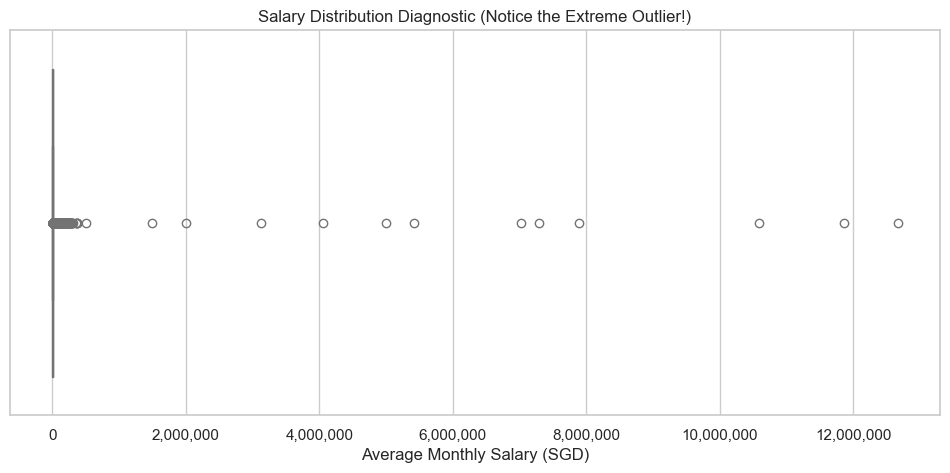

Statistical 'Normal' Range: $-1000.00 to $9400.00
✅ Removed 70837 outliers. Final clean dataset size: 973760


In [5]:
# 1. Check for the extreme outlier first
max_val = df['average_salary'].max()
print(f"The maximum salary in the dataset is: ${max_val:,.2f}")

# 2. Visualizing with a readable scale
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['average_salary'], color='lightgreen')

# Use ScalarFormatter to avoid scientific notation (1e7)
plt.ticklabel_format(style='plain', axis='x')

# Add commas to numbers (e.g., 1,000,000 instead of 1000000)
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Salary Distribution Diagnostic (Notice the Extreme Outlier!)')
plt.xlabel('Average Monthly Salary (SGD)')
plt.show()

# Calculating IQR bounds
Q1 = df['average_salary'].quantile(0.25)
Q3 = df['average_salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Statistical 'Normal' Range: ${lower_bound:.2f} to ${upper_bound:.2f}")

# Filtering out extremes
df_clean = df[(df['average_salary'] >= lower_bound) & (df['average_salary'] <= upper_bound)].copy()

outliers_removed = len(df) - len(df_clean)
print(f"✅ Removed {outliers_removed} outliers. Final clean dataset size: {len(df_clean)}")

## Other Types of Outlier Treatments

### 1. Clipping (Winsorization)

Clipping is a **transformation technique** rather than a deletion method. Instead of removing a row, you **cap** extreme values at a specified threshold (e.g., the 99th percentile).

**Best for:**  
When outliers are valid data points (e.g., a CEO’s salary), but they are so extreme that they distort model performance or skew summary statistics like the mean.

**Logic:**  
If a salary is greater than \$50,000, it is reset to exactly \$50,000.

---

### 2. Z-Score Method

This method is based on **standard deviations**. It measures how far a data point is from the mean in terms of spread.

**Formula:**

\[
z = \frac{x - \mu}{\sigma}
\]

Where:
- \(x\) = data point  
- \(\mu\) = mean  
- \(\sigma\) = standard deviation  

**Threshold:**  
Typically, values with a Z-score > 3 or < -3 are considered outliers.

**Best for:**  
Data that follows a **normal (bell curve) distribution**.

---

## Comparison Table

| Method        | Strategy       | Outcome                                              |
|--------------|----------------|------------------------------------------------------|
| IQR Filter   | Trimming       | Removes the rows entirely                            |
| Clipping     | Winsorization  | Keeps rows but caps extreme values                  |
| Z-Score      | Statistical filtering | Uses standard deviations; assumes normal distribution |

## 6. Addressing "Hidden" Data: Unpacking JSON

As identified in **Step C** of our framework, the `categories` column is "Available but Hidden" inside JSON-formatted strings. To make this data usable for future sector-based analysis, we must unpack it.

In [6]:
def extract_main_category(json_str):
    """Extracts the first category name from the JSON string."""
    try:
        data = json.loads(json_str.replace("'", '"')) # Standardize quotes
        return data[0]['category'] if data else "Uncategorized"
    except:
        return "Uncategorized"

# Applying transformation to unlock hidden data
df_clean['primary_category'] = df_clean['categories'].apply(extract_main_category)

print("✅ Hidden 'categories' data unpacked successfully!")
display(df_clean[['title', 'primary_category', 'average_salary']].head())

✅ Hidden 'categories' data unpacked successfully!


,title,primary_category,average_salary
1047556,(Senior) Business Development Executive,Sales / Retail,4000.00
1047636,Accounts Payable Executive,Accounting / Auditing / Taxation,3500.00
1047616,ACCOUNT EXECUTIVE,Accounting / Auditing / Taxation,3150.00
1047617,Facilities Maintenance Officer,Logistics / Supply Chain,2150.00
1047618,HR Admin Coordinator,Admin / Secretarial,3000.00


## 7 Final Clean Data Summary
The data is now prepared for our original business question: benchmarking salaries for different position levels.

--- Salary Benchmarks for Target Roles ---
Market-wide Global Gap: 58.73%


positionLevels,Junior Executive,Senior Executive,pct_diff,global_gap
primary_category,,,,
Legal,4500.00,6500.00,44.44,58.73
Risk Management,4250.00,5750.00,35.29,58.73
Information Technology,4000.00,6825.00,70.62,58.73
Banking and Finance,4000.00,6000.00,50.00,58.73
Personal Care / Beauty,3900.00,4000.00,2.56,58.73
Consulting,3600.00,5500.00,52.78,58.73
Engineering,3600.00,5500.00,52.78,58.73
Professional Services,3500.00,4500.00,28.57,58.73
Insurance,3500.00,5000.00,42.86,58.73


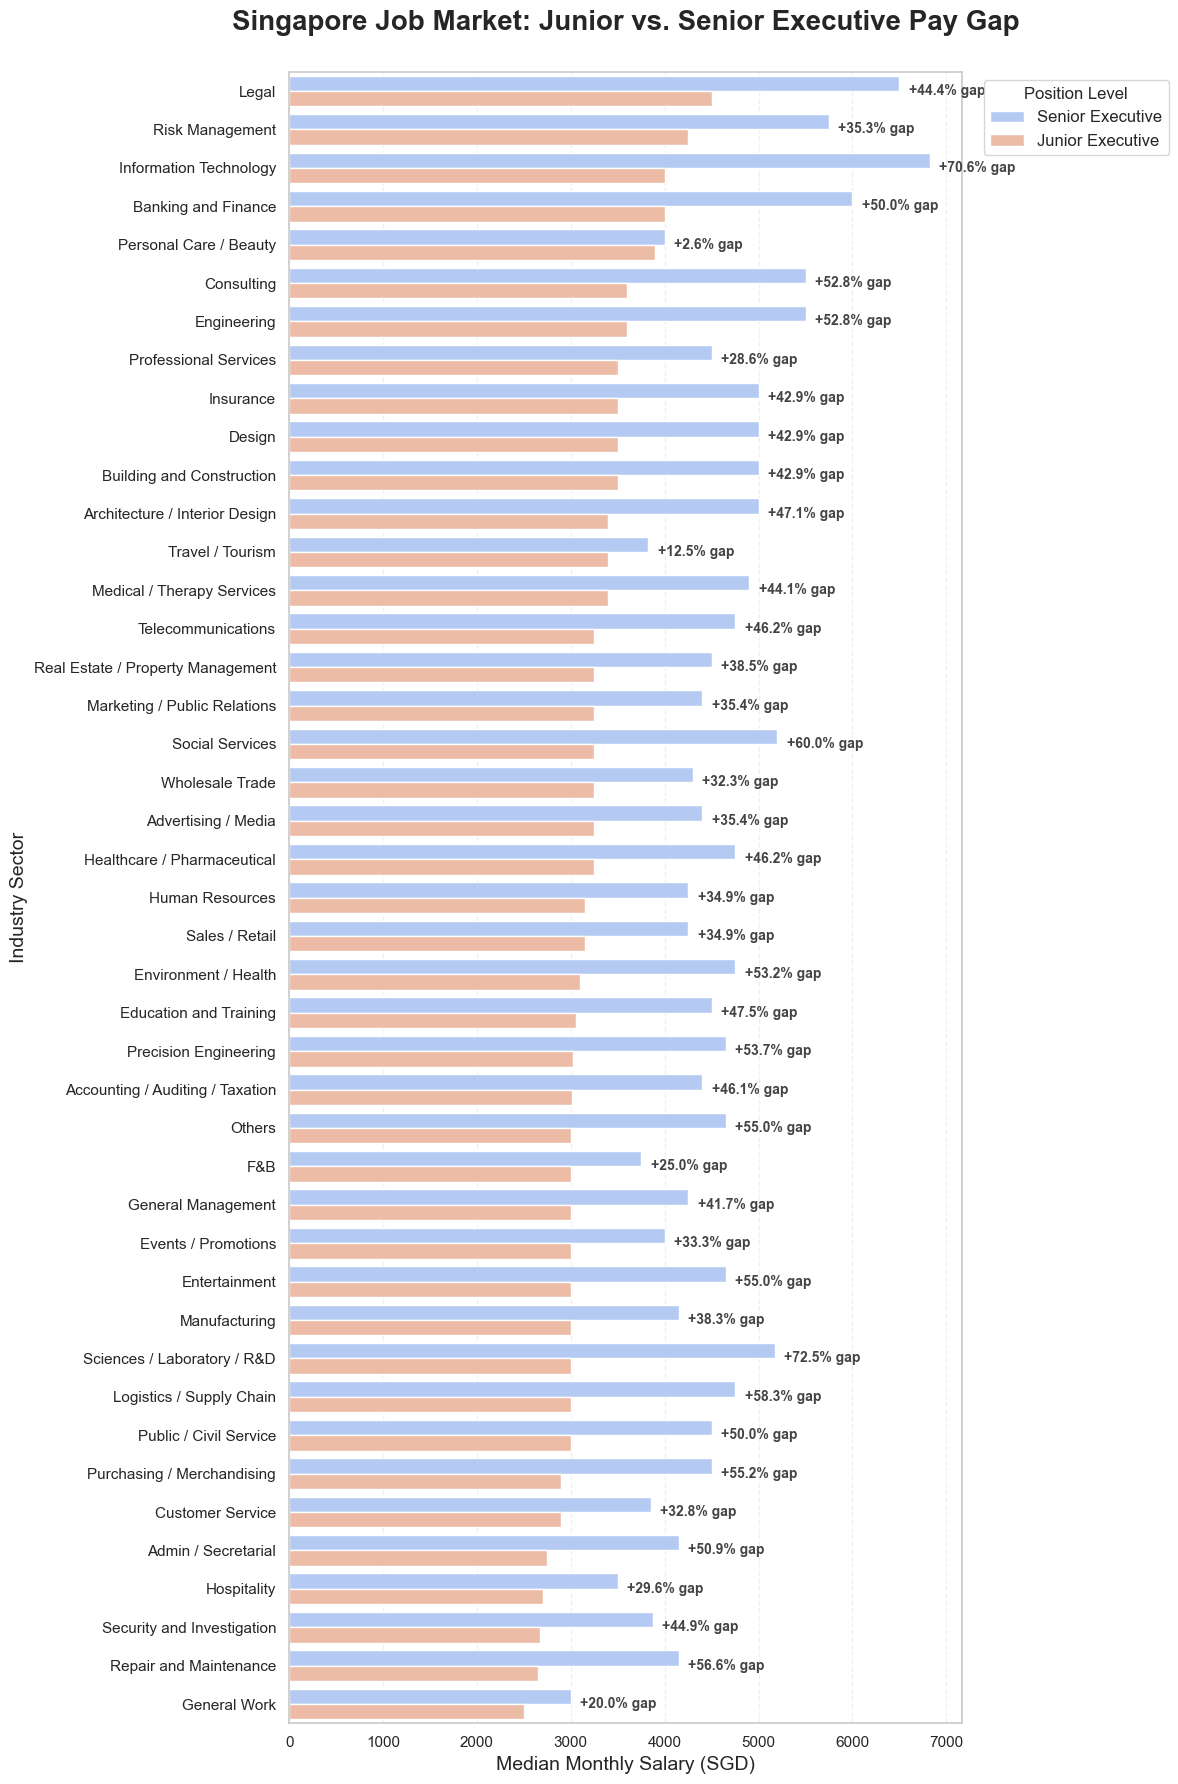

In [7]:
# 1. Data Preparation & Statistical Calculation
target_levels = ['Junior Executive', 'Senior Executive']
viz_df = df_clean[df_clean['positionLevels'].isin(target_levels)].copy()

# Calculate sector-specific stats
stats = viz_df.groupby(['primary_category', 'positionLevels'])['average_salary'].median().unstack()
stats['pct_diff'] = ((stats['Senior Executive'] - stats['Junior Executive']) / stats['Junior Executive']) * 100

# NEW: Calculate Global Benchmarks (All Sectors combined)
global_jnr = viz_df[viz_df['positionLevels'] == 'Junior Executive']['average_salary'].median()
global_snr = viz_df[viz_df['positionLevels'] == 'Senior Executive']['average_salary'].median()
global_pct_diff = ((global_snr - global_jnr) / global_jnr) * 100

# Add Global Gap column to stats for easy comparison
stats['global_gap'] = global_pct_diff

# Determine sorting order (Sorted by Junior Executive salary as requested)
order = stats.sort_values('Junior Executive', ascending=False).index

# 2. Display Benchmark Table in Full
print("--- Salary Benchmarks for Target Roles ---")
print(f"Market-wide Global Gap: {global_pct_diff:.2f}%")
pd.set_option('display.max_rows', None) 
display(stats[['Junior Executive', 'Senior Executive', 'pct_diff', 'global_gap']].sort_values('Junior Executive', ascending=False))

# 3. Create the Visualization
plt.figure(figsize=(12, 18))

# CRITICAL: Initialize the plot and assign it to 'ax' BEFORE attempting to annotate
ax = sns.barplot(
    data=viz_df, 
    x='average_salary', 
    y='primary_category', 
    hue='positionLevels', 
    order=order, 
    estimator=np.median, 
    errorbar=None, 
    palette='coolwarm'
)

# 4. Annotate Percentage Gaps on the Graph
# This loop iterates through each sector and places the label next to the bars
for i, category in enumerate(order):
    if category in stats.index:
        diff = stats.loc[category, 'pct_diff']
        senior_val = stats.loc[category, 'Senior Executive']
        
        # Check if values are valid (not NaN) before drawing
        if not np.isnan(diff) and not np.isnan(senior_val):
            ax.text(
                senior_val + 100, # X-position (offset slightly from the end of the bar)
                i,                # Y-position (aligned with the sector index)
                f"{diff:+.1f}% gap", 
                va='center', 
                fontweight='bold', 
                color='#444', 
                fontsize=10
            )

# Final Polish
plt.title('Singapore Job Market: Junior vs. Senior Executive Pay Gap', fontsize=20, pad=30, fontweight='bold')
plt.xlabel('Median Monthly Salary (SGD)', fontsize=14)
plt.ylabel('Industry Sector', fontsize=14)
plt.legend(title='Position Level', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('salary_benchmark_final.png')
plt.show()

### **What This Chart Shows:**

- **X-axis:** Monthly salary in SGD (higher equals more pay)
- **Y-axis:** Industry sectors, ordered from highest to lowest median salary
- **Bars:** Compare Junior Executive (one color) vs. Senior Executive (another color)
- **Gap between bars:** Visual representation of career growth potential in each sector

### **Key Sector Insights:**

**Salary Growth Potential:**
- Sectors with larger gaps between Junior and Senior roles offer more growth opportunity
- Sectors with smaller gaps may have more compressed salary structures (less room for growth)

**For Job Seekers:**
1. Identify your target sector
2. Find your position level (Junior Executive, Senior Executive, etc.)
3. Use the **median salary** as your baseline expectation
4. Potentially explore other sectors with better growth opportunity

## 8 **The Data Journey**

We took a raw, messy dataset and transformed it into reliable insights. Here is what we did:

| Step | Action | Why It Matters |
| :--- | :--- | :--- |
| Framework | Defined business goal before touching data | Ensures cleaning is purposeful |
| Exploration | Examined structure, missing values, data types | Understanding prevents mistakes |
| Deduplication | Removed exact row duplicates | Prevents inflated counts |
| Missing Values | Dropped rows/columns with missing data | Maintains data integrity |
| Outliers | Removed salary outliers using IQR method | Avoids skewing of salary data |
| Transformation | Extracted primary categories from JSON | Makes nested data usable |
| Analysis | Extracted benchmarks by sector and level | Answers original business question |

### **Actionable Insights for Job Seekers:**

Using our cleaned data, we helped job seekers
1. Determine **Median salary benchmarks** for Junior and Senior Executives across multiple sectors
2. Identify sectors with attractive salary growth potential